Dataset Loaded Successfully!
Shape: (50, 8)

First 5 Records:
     Name Attendance  Assessment marks  Assignment score  Study hours  \
0    Riya        90%              20.0                24          1.6   
1  Monica        60%              18.0                20          3.0   
2    John        88%              15.0                28          3.0   
3    Soha        89%              13.5                29          3.4   
4  Ritika        99%              17.5                21          2.8   

   Sem marks  Participation  no.of backlog  
0       45.1             81              0  
1       94.2             74              0  
2       54.3             78              0  
3       80.6             88              0  
4       61.9             56              0  

Missing Values:
Name                0
Attendance          0
Assessment marks    0
Assignment score    0
Study hours         0
Sem marks           0
Participation       0
no.of backlog       0
dtype: int64

Features:
   Attendanc

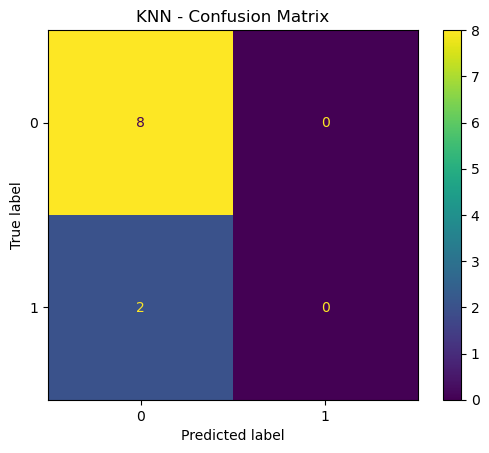

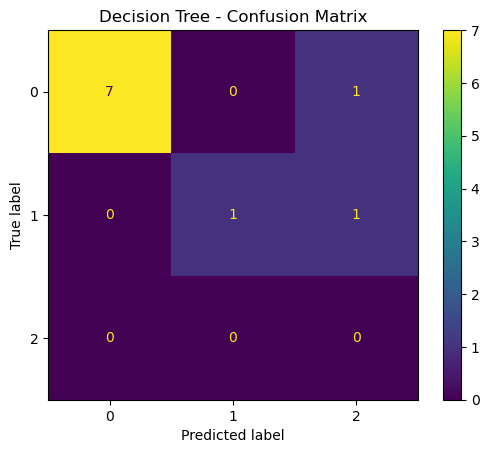

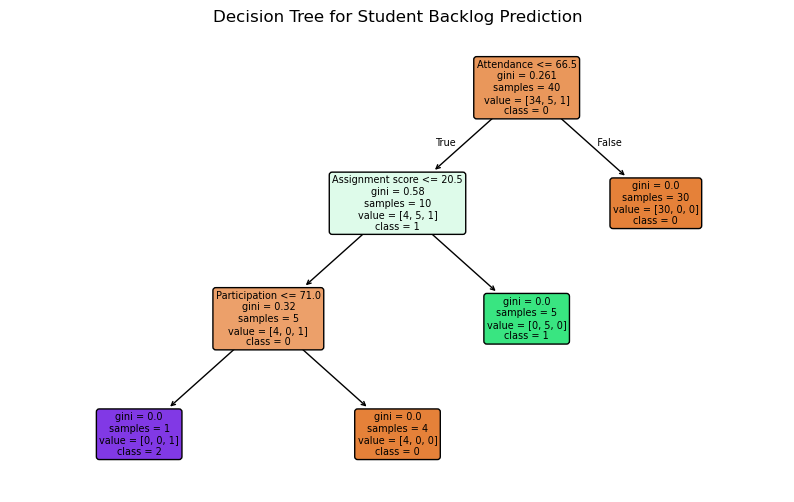


NEW STUDENT PREDICTION
KNN Predicted Backlog: 0
Decision Tree Predicted Backlog: 0


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

file_path = "student_performance_data.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
print("\nFirst 5 Records:")
print(df.head())


# Remove % symbol from Attendance
df["Attendance"] = df["Attendance"].str.replace("%", "").astype(float)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing numeric values with median
numeric_columns = [
    "Attendance",
    "Assessment marks",
    "Assignment score",
    "Study hours",
    "Sem marks",
    "Participation",
    "no.of backlog"
]

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)


X = df[
    [
        "Attendance",
        "Assessment marks",
        "Assignment score",
        "Study hours",
        "Sem marks",
        "Participation"
    ]
]

y = df["no.of backlog"]

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

print("\nTraining Records:", len(X_train))
print("Testing Records:", len(X_test))



# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Create KNN Model
knn = KNeighborsClassifier(n_neighbors=5)

# Train Model
knn.fit(X_train_scaled, y_train)

# Prediction
y_pred_knn = knn.predict(X_test_scaled)


# KNN Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("\n==============================")
print("KNN MODEL")
print("==============================")

print("Accuracy:", knn_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, zero_division=0))
print("\n\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\n\n")

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

# Train Model
dt.fit(X_train, y_train)

# Prediction
y_pred_dt = dt.predict(X_test)


# Decision Tree Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("\n====================================")
print("DECISION TREE MODEL")
print("==============================")

print("Accuracy:", dt_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\n====================================")
print("MODEL COMPARISON")
print("====================================")

print(f"KNN Accuracy           : {knn_accuracy:.2%}")
print(f"Decision Tree Accuracy : {dt_accuracy:.2%}")

print("\n\n")

if knn_accuracy > dt_accuracy:
    print("\nBest Model: KNN")
elif dt_accuracy > knn_accuracy:
    print("\nBest Model: Decision Tree")
else:
    print("\nBoth models have the same accuracy.")


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn
)

plt.title("KNN - Confusion Matrix")
plt.show()

print("\n\n")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()


print("\n\n")
plt.figure(figsize=(10, 6))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=7
)

plt.title("Decision Tree for Student Backlog Prediction")
plt.show()



new_student = pd.DataFrame({
    "Attendance": [85],
    "Assessment marks": [17],
    "Assignment score": [25],
    "Study hours": [4.5],
    "Sem marks": [78],
    "Participation": [85]
})


# KNN prediction
new_student_scaled = scaler.transform(new_student)

knn_prediction = knn.predict(new_student_scaled)


# Decision Tree prediction
dt_prediction = dt.predict(new_student)


print("\n====================================")
print("NEW STUDENT PREDICTION")


print("KNN Predicted Backlog:",
      knn_prediction[0])

print("Decision Tree Predicted Backlog:",
      dt_prediction[0])

In [37]:
from sklearn.linear_model import LogisticRegression

# Created Logistic Regression Model
logistic = LogisticRegression(max_iter=1000)

# Train Model
logistic.fit(X_train_scaled, y_train)

# Prediction
y_pred_logistic = logistic.predict(X_test_scaled)

# Calculate Accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

print("Accuracy:", logistic_accuracy)
print(f"Accuracy Percentage: {logistic_accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_logistic
))

# Scale new student
new_student_scaled = scaler.transform(new_student)

# Logistic Regression Prediction
logistic_prediction = logistic.predict(new_student_scaled)

print(
    "Logistic Regression Predicted Backlog:",
    logistic_prediction[0]
)


LOGISTIC REGRESSION
Accuracy: 1.0
Accuracy Percentage: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


Confusion Matrix:
[[8 0]
 [0 2]]
Logistic Regression Predicted Backlog: 0
